# MADDPG Model Inspector
**Multi-Agent System for Fintech Regulatory Compliance**  
*Ismail Dogan*

This notebook inspects the saved `.pth` checkpoint files **directly from their state dicts** — no model class reconstruction needed for architecture exploration.

> A PyTorch `.pth` file is just a Python dict. Every key is a layer name, every value is the weight tensor. The architecture is fully visible just from reading those keys and shapes.

## 1. Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MODELS_DIR = Path("../trained_models")

CHECKPOINTS = {
    "Actor — Transaction Pattern Agent": MODELS_DIR / "actor_transaction.pth",
    "Actor — Customer Risk Agent":       MODELS_DIR / "actor_customer.pth",
    "Actor — Network Analysis Agent":    MODELS_DIR / "actor_network.pth",
    "Critic — Centralized":              MODELS_DIR / "critic.pth",
}

print(f"PyTorch {torch.__version__}\n")
for label, path in CHECKPOINTS.items():
    size = f"{path.stat().st_size / 1024:.0f} KB" if path.exists() else "MISSING ❌"
    print(f"  {'✅' if path.exists() else '❌'}  {label:<40s}  {size}")

PyTorch 2.5.1

  ✅  Actor — Transaction Pattern Agent         411 KB
  ✅  Actor — Customer Risk Agent               411 KB
  ✅  Actor — Network Analysis Agent            411 KB
  ✅  Critic — Centralized                      415 KB


## 2. Architecture — Layer-by-Layer Table
Read directly from the state dict keys. No class reconstruction needed — the keys encode the full architecture.

In [2]:
def describe_checkpoint(label, path):
    sd = torch.load(path, map_location="cpu", weights_only=True)
    
    print(f"\n{'━'*70}")
    print(f"  {label}")
    print(f"  File: {path.name}  ({path.stat().st_size/1024:.0f} KB)")
    print(f"{'━'*70}")
    print(f"  {'Layer key':<35s} {'Shape':<25s} {'#Params':>10s}")
    print(f"  {'─'*68}")
    
    total = 0
    for key, tensor in sd.items():
        shape  = list(tensor.shape)
        n      = tensor.numel()
        total += n
        print(f"  {key:<35s} {str(shape):<25s} {n:>10,}")
    
    print(f"  {'─'*68}")
    print(f"  {'TOTAL TRAINABLE PARAMETERS':<35s} {'':25s} {total:>10,}")

for label, path in CHECKPOINTS.items():
    describe_checkpoint(label, path)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Actor — Transaction Pattern Agent
  File: actor_transaction.pth  (411 KB)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Layer key                           Shape                        #Params
  ────────────────────────────────────────────────────────────────────
  fc1.weight                          [256, 6]                       1,536
  fc1.bias                            [256]                            256
  bn1.weight                          [256]                            256
  bn1.bias                            [256]                            256
  bn1.running_mean                    [256]                            256
  bn1.running_var                     [256]                            256
  bn1.num_batches_tracked             []                                 1
  fc2.weight                          [256, 256]                    65,536
  fc2.bias                         

## 3. Network Topology Summary
Human-readable summary of input → hidden → output dimensions — useful for architecture diagrams and documentation.

In [3]:
def topology_summary(label, path):
    sd = torch.load(path, map_location="cpu", weights_only=True)
    
    # Pull only Linear weight layers (skip bias and BatchNorm)
    linear_weights = {k: v for k, v in sd.items() if k.endswith(".weight") and "bn" not in k}
    
    layers = []
    for key, tensor in linear_weights.items():
        out_dim, in_dim = tensor.shape
        layers.append((key.replace(".weight", ""), in_dim, out_dim))
    
    print(f"\n{label}")
    print(f"  {'Layer':<12s}  {'Input dim':>10s}  →  {'Output dim':>10s}  Activation")
    print(f"  {'─'*55}")
    for i, (name, in_d, out_d) in enumerate(layers):
        activation = "Softmax" if i == len(layers)-1 and "actor" in path.name else \
                     "Linear"  if i == len(layers)-1 else "ReLU + BN"
        print(f"  {name:<12s}  {in_d:>10d}  →  {out_d:>10d}  {activation}")
    
    # Decode what the input represents
    first_in = layers[0][1]
    if first_in == 6:
        print(f"\n  Input (dim=6): [txn_prob, txn_risk/100, cust_prob, cust_risk/100, net_prob, net_risk/100]")
    elif first_in == 12:
        print(f"\n  Input (dim=12): global state(6) + agent actions one-hot(2×3=6)")
    last_out = layers[-1][2]
    if last_out == 2:
        print(f"  Output (dim=2): [P(BLOCK), P(ALLOW)]  →  argmax = final decision")
    elif last_out == 1:
        print(f"  Output (dim=1): Q-value scalar  →  expected cumulative reward")

for label, path in CHECKPOINTS.items():
    topology_summary(label, path)


Actor — Transaction Pattern Agent
  Layer          Input dim  →  Output dim  Activation
  ───────────────────────────────────────────────────────
  fc1                    6  →         256  ReLU + BN
  fc2                  256  →         256  ReLU + BN
  fc3                  256  →         128  ReLU + BN
  fc4                  128  →           2  Softmax

  Input (dim=6): [txn_prob, txn_risk/100, cust_prob, cust_risk/100, net_prob, net_risk/100]
  Output (dim=2): [P(BLOCK), P(ALLOW)]  →  argmax = final decision

Actor — Customer Risk Agent
  Layer          Input dim  →  Output dim  Activation
  ───────────────────────────────────────────────────────
  fc1                    6  →         256  ReLU + BN
  fc2                  256  →         256  ReLU + BN
  fc3                  256  →         128  ReLU + BN
  fc4                  128  →           2  Softmax

  Input (dim=6): [txn_prob, txn_risk/100, cust_prob, cust_risk/100, net_prob, net_risk/100]
  Output (dim=2): [P(BLOCK), P(ALLOW)] 

## 4. Weight Statistics — Summary Table
Mean, std, min, max for every Linear weight layer across all models. Useful for understanding the current state of each network after training.

In [4]:
print(f"\n{'Model':<38s} {'Layer':<8s} {'Mean':>9s} {'Std':>9s} {'Min':>9s} {'Max':>9s} {'#Params':>9s}")
print("─" * 92)

for label, path in CHECKPOINTS.items():
    sd = torch.load(path, map_location="cpu", weights_only=True)
    short = label.split("—")[1].strip()
    
    linear_weights = {k: v for k, v in sd.items() if k.endswith(".weight") and "bn" not in k}
    for i, (key, tensor) in enumerate(linear_weights.items()):
        w = tensor.numpy().flatten()
        layer_label = short if i == 0 else ""
        print(f"  {layer_label:<36s} {'fc'+str(i+1):<8s} {w.mean():>+9.5f} {w.std():>9.5f} {w.min():>+9.5f} {w.max():>+9.5f} {len(w):>9,}")
    print()


Model                                  Layer         Mean       Std       Min       Max   #Params
────────────────────────────────────────────────────────────────────────────────────────────
  Transaction Pattern Agent            fc1       +0.00163   0.08731  -0.15101  +0.15186     1,536
                                       fc2       -0.00048   0.06253  -0.11015  +0.11022    65,536
                                       fc3       -0.00073   0.07225  -0.12695  +0.12682    32,768
                                       fc4       +0.00334   0.12257  -0.21175  +0.21327       256

  Customer Risk Agent                  fc1       +0.00231   0.08619  -0.15142  +0.15170     1,536
                                       fc2       -0.00046   0.06251  -0.11016  +0.10999    65,536
                                       fc3       -0.00058   0.07209  -0.12649  +0.12623    32,768
                                       fc4       +0.00569   0.12202  -0.21308  +0.21428       256

  Network Analysis Age

## 5. Weight Distribution Plots
Histogram of every Linear layer per model. For a freshly trained model on 2 experiences you'll see narrow Xavier-initialized distributions — they broaden and shift as training accumulates.

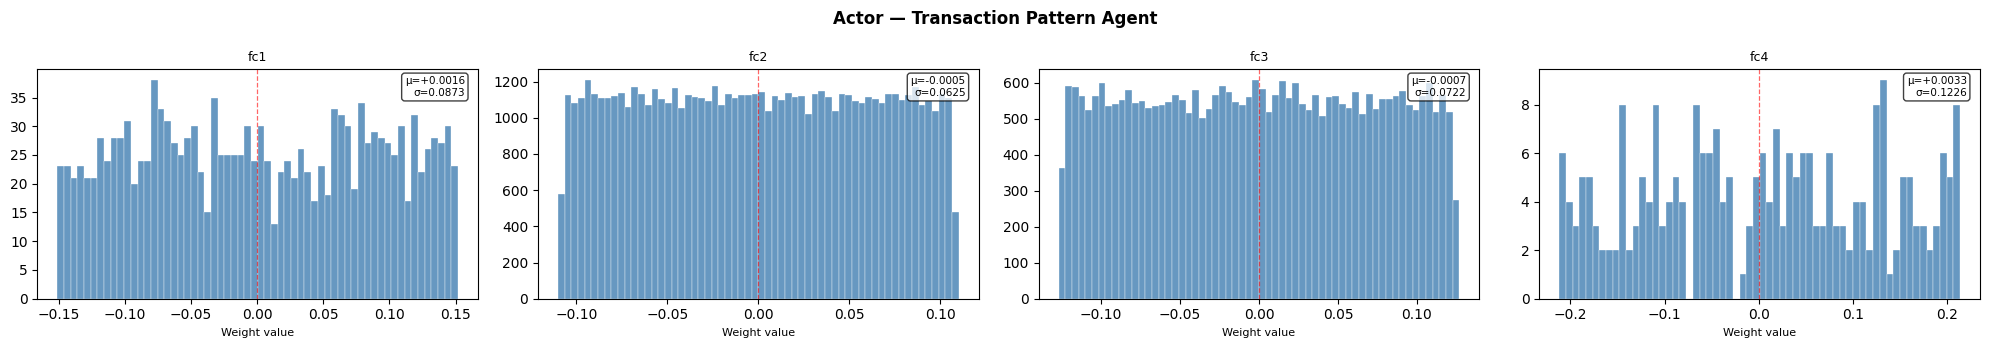

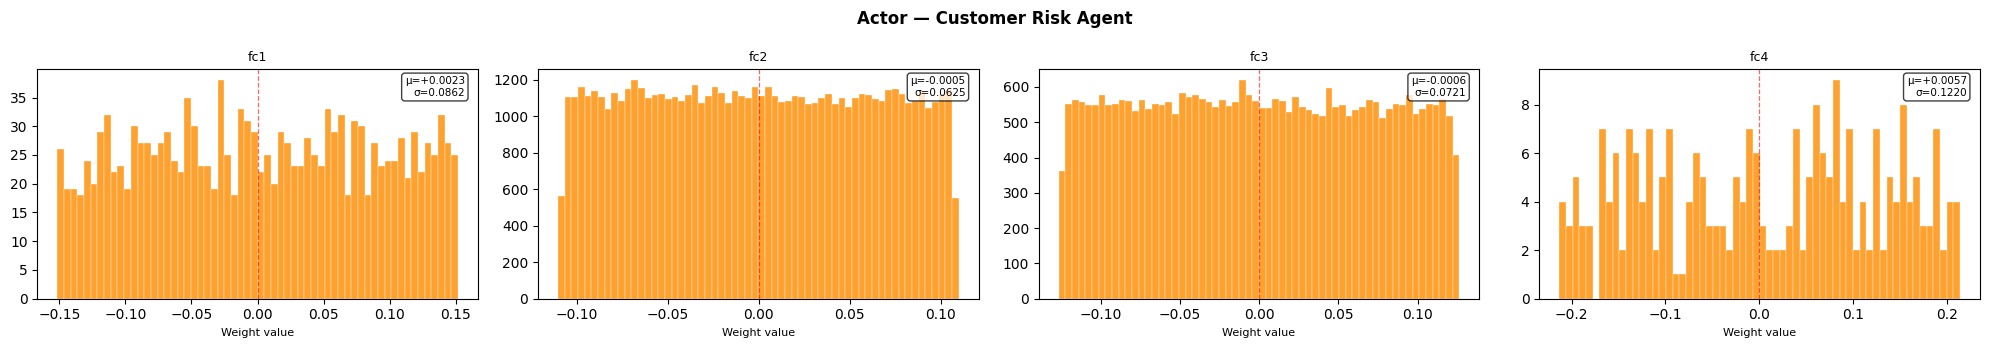

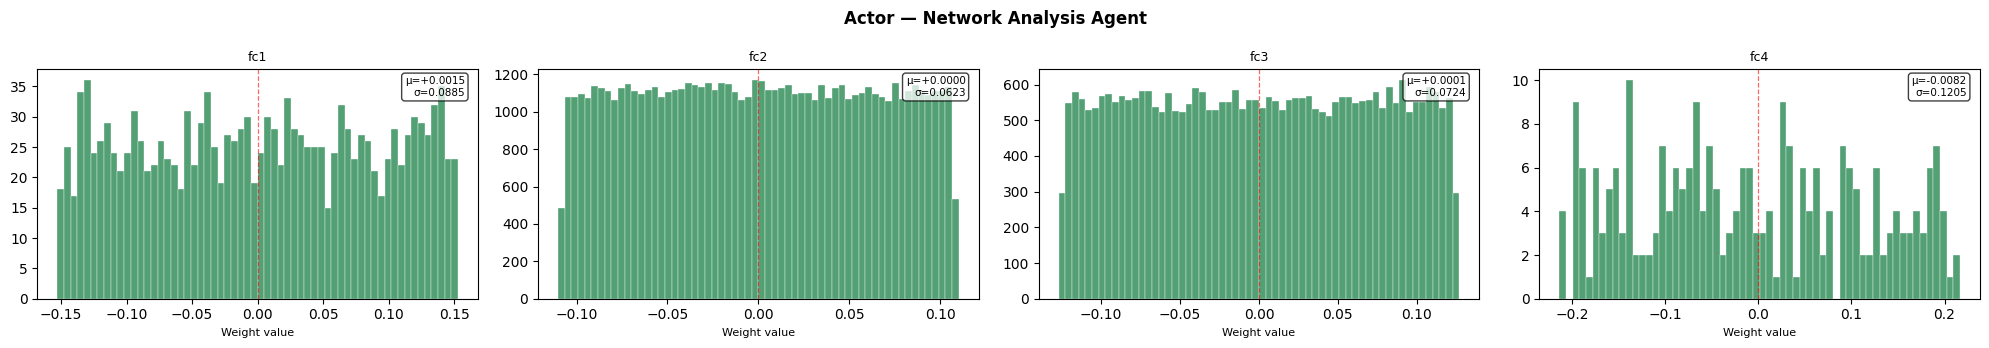

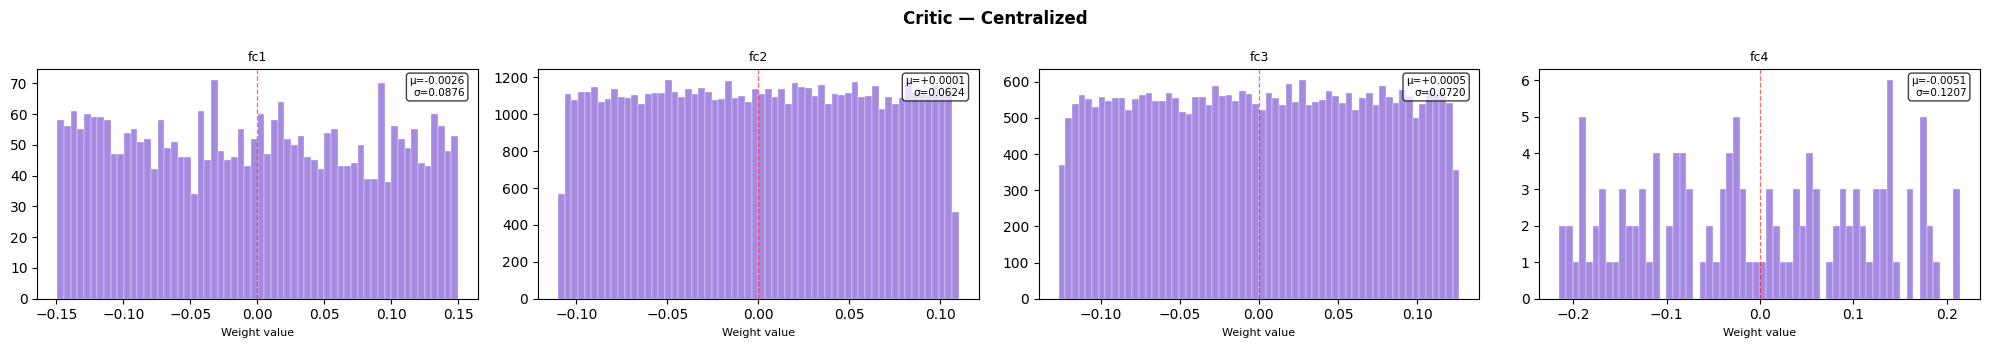

In [5]:
COLORS = {
    "Actor — Transaction Pattern Agent": "steelblue",
    "Actor — Customer Risk Agent":       "darkorange",
    "Actor — Network Analysis Agent":    "seagreen",
    "Critic — Centralized":              "mediumpurple",
}

for label, path in CHECKPOINTS.items():
    sd = torch.load(path, map_location="cpu", weights_only=True)
    linear_weights = [(k, v) for k, v in sd.items() if k.endswith(".weight") and "bn" not in k]

    fig, axes = plt.subplots(1, len(linear_weights), figsize=(5 * len(linear_weights), 3.5))
    if len(linear_weights) == 1:
        axes = [axes]
    fig.suptitle(label, fontsize=12, fontweight="bold")

    for ax, (key, tensor) in zip(axes, linear_weights):
        w = tensor.numpy().flatten()
        ax.hist(w, bins=60, color=COLORS[label], alpha=0.82, edgecolor="white", linewidth=0.3)
        ax.set_title(key.replace(".weight", ""), fontsize=9)
        ax.set_xlabel("Weight value", fontsize=8)
        ax.axvline(0, color="red", linestyle="--", linewidth=0.9, alpha=0.6)
        stats = f"μ={w.mean():+.4f}\nσ={w.std():.4f}"
        ax.text(0.97, 0.97, stats, transform=ax.transAxes, fontsize=7.5,
                va="top", ha="right", bbox=dict(boxstyle="round", fc="white", alpha=0.75))

    plt.tight_layout()
    plt.show()

## 6. How Actors Differ From Each Other
Even though all 3 Actor networks have identical architecture, they are trained with different gradient signals (each maximises its own Q contribution). This cell shows whether their weights have diverged or remained similar.

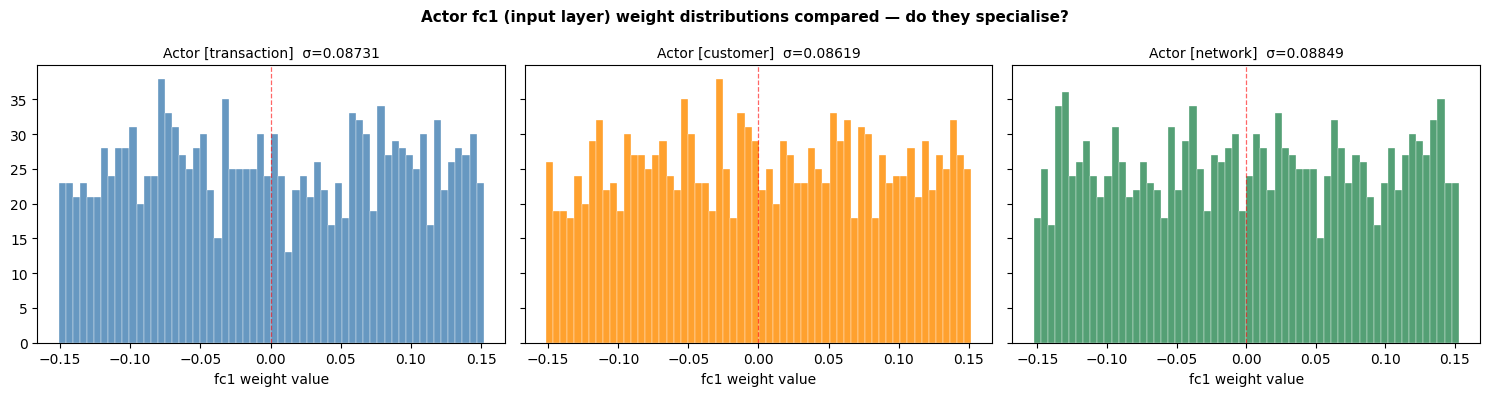


Mean absolute weight difference between actors (fc1.weight):
  transaction vs customer: 0.099345  ← diverged
  transaction vs network: 0.101379  ← diverged
  customer vs network: 0.099336  ← diverged


In [6]:
actor_names  = ["transaction", "customer", "network"]
actor_labels = [f"Actor — {n.title()} Pattern Agent" if n == "transaction" else
                f"Actor — {n.title()} Risk Agent"    if n == "customer"    else
                f"Actor — {n.title()} Analysis Agent" for n in actor_names]
actor_colors = ["steelblue", "darkorange", "seagreen"]
actor_sds    = [torch.load(MODELS_DIR / f"actor_{n}.pth", map_location="cpu", weights_only=True)
                for n in actor_names]

# Compare fc1.weight (input layer) distributions side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Actor fc1 (input layer) weight distributions compared — do they specialise?",
             fontsize=11, fontweight="bold")

for ax, sd, name, color in zip(axes, actor_sds, actor_names, actor_colors):
    w = sd["fc1.weight"].numpy().flatten()
    ax.hist(w, bins=60, color=color, alpha=0.82, edgecolor="white", linewidth=0.3)
    ax.set_title(f"Actor [{name}]  σ={w.std():.5f}", fontsize=10)
    ax.set_xlabel("fc1 weight value")
    ax.axvline(0, color="red", linestyle="--", linewidth=0.9, alpha=0.6)

plt.tight_layout()
plt.show()

# Pairwise mean absolute difference between all actor layers
print("\nMean absolute weight difference between actors (fc1.weight):")
for i in range(len(actor_names)):
    for j in range(i+1, len(actor_names)):
        diff = (actor_sds[i]["fc1.weight"] - actor_sds[j]["fc1.weight"]).abs().mean().item()
        print(f"  {actor_names[i]} vs {actor_names[j]}: {diff:.6f}  {'← diverged' if diff > 0.001 else '← still similar (need more training)'}")

## 7. Centralized Critic — CTDE Architecture Analysis

**Centralized Training, Decentralized Execution (CTDE)** is the core architectural paradigm of MADDPG:

| | Training time | Execution time |
|---|---|---|
| **Actors** | Receive gradient signals from the Critic which sees all actions | See **only** local observation |
| **Critic** | Observes **joint** state + all agent actions → outputs Q-value | Not used at runtime |

The Critic's input vector is dim=12, structured as:

```
[ s₀  s₁  s₂  s₃  s₄  s₅ | a⁰₀ a⁰₁ | a¹₀ a¹₁ | a²₀ a²₁ ]
  ←────── state (6) ──────→  ←txn(2)→  ←cst(2)→  ←net(2)→
```

The heatmap below visualises how `fc1` (the Critic's input layer, shape `[256 × 12]`) decomposes
this joint input — showing which hidden neurons respond primarily to **state** features vs. **agent actions**.


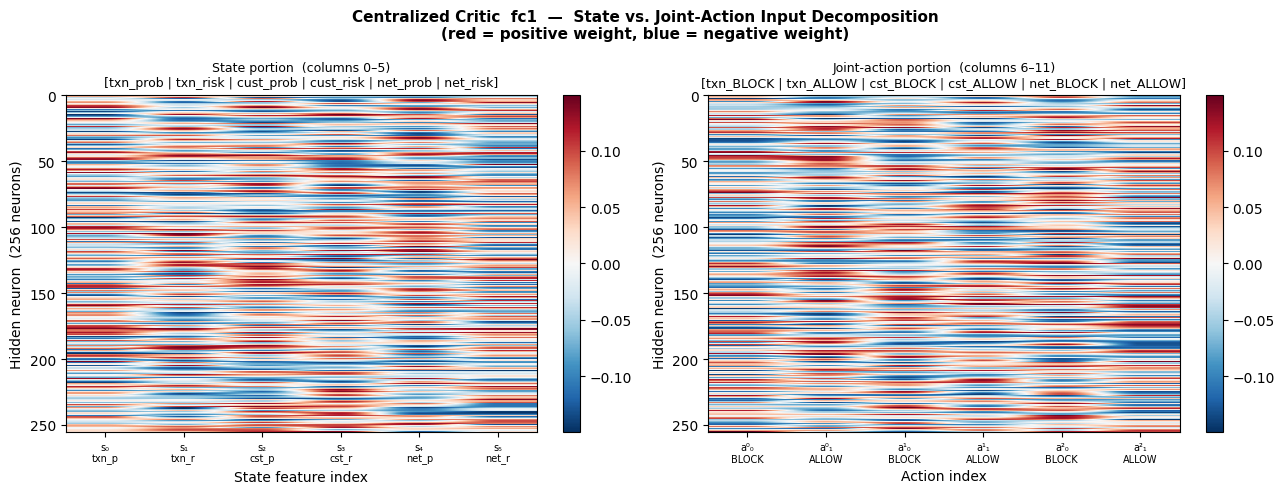


Critic fc1 input weight L2-norms  (normalised per column count):
  State  portion  (6 cols):  3.4148   per-column avg: 0.5691
  Action portion  (6 cols):  3.4517   per-column avg: 0.5753
  Ratio  state / action:     0.9893  →  action-dominant


Model                                        #Params  Role
  ────────────────────────────────────────────────────────────────────────
  Actor — Transaction Pattern Agent            103,301  Decentralised decision-maker  (runs at inference)
  Actor — Customer Risk Agent                  103,301  Decentralised decision-maker  (runs at inference)
  Actor — Network Analysis Agent               103,301  Decentralised decision-maker  (runs at inference)
  Critic — Centralized                         104,708  Centralised value estimator  (training only)


In [7]:
critic_sd = torch.load(MODELS_DIR / "critic.pth", map_location="cpu", weights_only=True)
fc1_w     = critic_sd["fc1.weight"]          # shape [256, 12]
vmax      = float(fc1_w.abs().max())

state_cols  = fc1_w[:, :6].numpy()           # columns that respond to state
action_cols = fc1_w[:, 6:].numpy()           # columns that respond to joint actions

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Centralized Critic  fc1  —  State vs. Joint-Action Input Decomposition\n"
    "(red = positive weight, blue = negative weight)",
    fontsize=11, fontweight="bold"
)

im0 = axes[0].imshow(state_cols, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title(
    "State portion  (columns 0–5)\n"
    "[txn_prob | txn_risk | cust_prob | cust_risk | net_prob | net_risk]",
    fontsize=9
)
axes[0].set_xlabel("State feature index")
axes[0].set_ylabel("Hidden neuron  (256 neurons)")
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["s₀\ntxn_p", "s₁\ntxn_r", "s₂\ncst_p", "s₃\ncst_r", "s₄\nnet_p", "s₅\nnet_r"], fontsize=7)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(action_cols, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title(
    "Joint-action portion  (columns 6–11)\n"
    "[txn_BLOCK | txn_ALLOW | cst_BLOCK | cst_ALLOW | net_BLOCK | net_ALLOW]",
    fontsize=9
)
axes[1].set_xlabel("Action index")
axes[1].set_ylabel("Hidden neuron  (256 neurons)")
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(["a⁰₀\nBLOCK", "a⁰₁\nALLOW", "a¹₀\nBLOCK", "a¹₁\nALLOW", "a²₀\nBLOCK", "a²₁\nALLOW"], fontsize=7)
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

# ── L2-norm comparison ───────────────────────────────────────────────────────
state_norm  = np.linalg.norm(state_cols)
action_norm = np.linalg.norm(action_cols)
ratio       = state_norm / action_norm

print(f"\nCritic fc1 input weight L2-norms  (normalised per column count):")
print(f"  State  portion  (6 cols):  {state_norm:.4f}   per-column avg: {state_norm/6:.4f}")
print(f"  Action portion  (6 cols):  {action_norm:.4f}   per-column avg: {action_norm/6:.4f}")
print(f"  Ratio  state / action:     {ratio:.4f}  →  {'state-dominant' if ratio > 1 else 'action-dominant'}")
print()

# ── Parameter count comparison ───────────────────────────────────────────────
print(f"\n{'Model':<40s}  {'#Params':>10s}  Role")
print("  " + "─" * 72)
for label, path in CHECKPOINTS.items():
    sd = torch.load(path, map_location="cpu", weights_only=True)
    n  = sum(t.numel() for t in sd.values())
    role = "Decentralised decision-maker  (runs at inference)" if "Actor" in label \
           else "Centralised value estimator  (training only)"
    print(f"  {label:<40s}  {n:>10,}  {role}")


## 8. Saving Figures for Documentation

Run the cell below to export **every figure in this notebook** to `../figures/` as:
- **`.pdf`** — vector format, scales to any print resolution (recommended for LaTeX / Word)
- **`.png`** — 300 DPI raster, suitable for slides or direct upload

---

**LaTeX snippet** to include a saved figure:

```latex
\begin{figure}[h]
    \centering
    \includegraphics[width=0.85\textwidth]{figures/critic_ctde_decomposition.pdf}
    \caption{Centralized Critic \texttt{fc1} weight decomposition: state input portion
             (columns 0--5) vs.\ joint-action input portion (columns 6--11).}
    \label{fig:critic-ctde}
\end{figure}
```

---

**Where each figure belongs in the document:**

| Saved filename | Notebook section | Suggested chapter |
|---|---|---|
| `weight_dist_*.pdf` | §5 Weight Distributions | Evaluation / Experiments |
| `actor_fc1_comparison.pdf` | §6 Actor Comparison | Evaluation / Discussion |
| `critic_ctde_decomposition.pdf` | §7 Critic CTDE | Architecture / System Design |


In [8]:
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

def save_fig(fig, filename):
    """Save a figure as both PDF (vector) and PNG (300 DPI raster)."""
    fig.savefig(FIGURES_DIR / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    print(f"  ✅  {filename}.pdf  +  {filename}.png")

print(f"Output directory: {FIGURES_DIR.resolve()}\n")

# ── 1. Weight distribution — one figure per model ───────────────────────────
for label, path in CHECKPOINTS.items():
    sd = torch.load(path, map_location="cpu", weights_only=True)
    linear_weights = [(k, v) for k, v in sd.items() if k.endswith(".weight") and "bn" not in k]

    fig, axes = plt.subplots(1, len(linear_weights), figsize=(5 * len(linear_weights), 3.5))
    if len(linear_weights) == 1:
        axes = [axes]
    fig.suptitle(label, fontsize=12, fontweight="bold")
    for ax, (key, tensor) in zip(axes, linear_weights):
        w = tensor.numpy().flatten()
        ax.hist(w, bins=60, color=COLORS[label], alpha=0.82, edgecolor="white", linewidth=0.3)
        ax.set_title(key.replace(".weight", ""), fontsize=9)
        ax.set_xlabel("Weight value", fontsize=8)
        ax.axvline(0, color="red", linestyle="--", linewidth=0.9, alpha=0.6)
        ax.text(0.97, 0.97, f"μ={w.mean():+.4f}\nσ={w.std():.4f}",
                transform=ax.transAxes, fontsize=7.5, va="top", ha="right",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))
    plt.tight_layout()
    slug = label.split("—")[1].strip().replace(" ", "_").lower()
    save_fig(fig, f"weight_dist_{slug}")
    plt.close()

# ── 2. Actor fc1 comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle("Actor fc1 (input layer) weight distributions compared", fontsize=11, fontweight="bold")
for ax, sd, name, color in zip(axes, actor_sds, actor_names, actor_colors):
    w = sd["fc1.weight"].numpy().flatten()
    ax.hist(w, bins=60, color=color, alpha=0.82, edgecolor="white", linewidth=0.3)
    ax.set_title(f"Actor [{name}]  σ={w.std():.5f}", fontsize=10)
    ax.set_xlabel("fc1 weight value")
    ax.axvline(0, color="red", linestyle="--", linewidth=0.9, alpha=0.6)
plt.tight_layout()
save_fig(fig, "actor_fc1_comparison")
plt.close()

# ── 3. Critic CTDE decomposition ─────────────────────────────────────────────
fc1_w = critic_sd["fc1.weight"]
vmax  = float(fc1_w.abs().max())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Centralized Critic fc1 — State vs. Joint-Action Input Decomposition",
             fontsize=11, fontweight="bold")
im0 = axes[0].imshow(fc1_w[:, :6].numpy(), aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[0].set_title("State portion (cols 0–5)", fontsize=9)
axes[0].set_xlabel("State feature"); axes[0].set_ylabel("Hidden neuron (256)")
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["s₀\ntxn_p","s₁\ntxn_r","s₂\ncst_p","s₃\ncst_r","s₄\nnet_p","s₅\nnet_r"], fontsize=7)
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(fc1_w[:, 6:].numpy(), aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[1].set_title("Joint-action portion (cols 6–11)", fontsize=9)
axes[1].set_xlabel("Action index"); axes[1].set_ylabel("Hidden neuron (256)")
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(["a⁰\nBLK","a⁰\nALW","a¹\nBLK","a¹\nALW","a²\nBLK","a²\nALW"], fontsize=7)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
save_fig(fig, "critic_ctde_decomposition")
plt.close()

print(f"\n✅  All figures saved to:  {FIGURES_DIR.resolve()}")


Output directory: /Users/ismaildogan/IdeaProjects/multi-agents-in-fintech-regulatory-compliance/ai-services/marl_orchestrator/training/figures

  ✅  weight_dist_transaction_pattern_agent.pdf  +  weight_dist_transaction_pattern_agent.png
  ✅  weight_dist_customer_risk_agent.pdf  +  weight_dist_customer_risk_agent.png
  ✅  weight_dist_network_analysis_agent.pdf  +  weight_dist_network_analysis_agent.png
  ✅  weight_dist_centralized.pdf  +  weight_dist_centralized.png
  ✅  actor_fc1_comparison.pdf  +  actor_fc1_comparison.png
  ✅  critic_ctde_decomposition.pdf  +  critic_ctde_decomposition.png

✅  All figures saved to:  /Users/ismaildogan/IdeaProjects/multi-agents-in-fintech-regulatory-compliance/ai-services/marl_orchestrator/training/figures
